# Análisis exploratorio de productos de maquillaje

Este notebook analiza productos reales obtenidos desde Makeup API y almacenados previamente en MongoDB.

El flujo usado es:

1. Conexión y lectura de datos.
2. Limpieza y construcción del DataFrame.
3. Cálculo de métricas principales.
4. Visualización de insights del comportamiento de precio, rating y colores.

Cada sección está separada para facilitar el análisis y resaltar los hallazgos más importantes.

In [81]:
# Imports and connection
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "EDA" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from etl.common.config import load_config
from etl.common.db import get_mongo_collection
from etl.transform.transform import transform_products

sns.set_theme(style="whitegrid")
custom_palette = ["#A54E4E", "#79CDC3", "#E9C46A", "#8A5C99", "#75D1A1"]
sns.set_palette(custom_palette)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "medium"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["grid.color"] = "#f0e8f2"


## 1. Conexión y carga de datos

En esta primera etapa conectamos con MongoDB, leemos los productos sin el campo interno `_id` y preparamos los datos para análisis.


In [82]:
# Read DB
cfg = load_config()
raw_collection = get_mongo_collection(cfg)

raw_products = list(raw_collection.find({}, {"_id": 0}))

print(f"Documentos leidos desde MongoDB: {len(raw_products)}")
raw_products[0]

Documentos leidos desde MongoDB: 931


{'id': 1048,
 'brand': 'colourpop',
 'name': 'Lippie Pencil',
 'price': '5.0',
 'price_sign': '$',
 'currency': 'CAD',
 'image_link': 'https://cdn.shopify.com/s/files/1/1338/0845/collections/lippie-pencil_grande.jpg?v=1512588769',
 'product_link': 'https://colourpop.com/collections/lippie-pencil',
 'website_link': 'https://colourpop.com',
 'description': 'Lippie Pencil A long-wearing and high-intensity lip pencil that glides on easily and prevents feathering. Many of our Lippie Stix have a coordinating Lippie Pencil designed to compliment it perfectly, but feel free to mix and match!',
 'rating': None,
 'category': 'pencil',
 'product_type': 'lip_liner',
 'tag_list': ['cruelty free', 'Vegan'],
 'created_at': '2018-07-08T23:45:08.056Z',
 'updated_at': '2018-07-09T00:53:23.301Z',
 'product_api_url': 'https://makeup-api.herokuapp.com/api/v1/products/1048.json',
 'api_featured_image': '//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/048/original/open-uri20180708-4-13o

## 2. Limpieza y construcción del DataFrame

A partir de los productos leídos, construimos un DataFrame limpio y agregamos atributos de análisis como rango de precio y etiquetas de rating.


In [83]:
# Create DataFrame and enrich features

df = transform_products(raw_products)
df_clean = df.copy()

df_clean["price_range"] = pd.cut(
    df_clean["price"],
    bins=[-1, 10, 20, 1000],
    labels=["Budget", "Regular", "Premium"],
)
df_clean["rating_label"] = pd.cut(
    df_clean["rating"],
    bins=[-0.1, 2.5, 4.0, 5.0],
    labels=["Bajo", "Medio", "Alto"],
)

df_clean.head()

,id,brand,name,product_type,category,price,rating,currency,tag_count,color_count,tags,price_range,rating_label
0,1048,colourpop,Lippie Pencil,lip_liner,pencil,5.0,NaN,CAD,2,34,"cruelty free, Vegan",Budget,NaN
1,1047,colourpop,Blotted Lip,lipstick,lipstick,5.5,NaN,CAD,2,7,"cruelty free, Vegan",Budget,NaN
2,1046,colourpop,Lippie Stix,lipstick,lipstick,5.5,NaN,CAD,2,46,"cruelty free, Vegan",Budget,NaN
3,1045,colourpop,No Filter Foundation,foundation,liquid,12.0,NaN,CAD,2,42,"cruelty free, Vegan",Regular,NaN
4,1044,boosh,Lipstick,lipstick,lipstick,26.0,NaN,CAD,2,15,"Chemical Free, Organic",Premium,NaN


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         931 non-null    object 
 2   name          931 non-null    object 
 3   product_type  931 non-null    object 
 4   category      931 non-null    object 
 5   price         917 non-null    float64
 6   rating        340 non-null    float64
 7   currency      931 non-null    object 
 8   tag_count     931 non-null    int64  
 9   color_count   931 non-null    int64  
 10  tags          931 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 80.1+ KB


In [85]:
df.isnull().sum()

id                0
brand             0
name              0
product_type      0
category          0
price            14
rating          591
currency          0
tag_count         0
color_count       0
tags              0
dtype: int64

In [86]:
df.describe(include="all")

,id,brand,name,product_type,category,price,rating,currency,tag_count,color_count,tags
count,931.000000,931,931,931,931,917.000000,340.000000,931,931.000000,931.000000,931
unique,NaN,58,913,10,15,NaN,NaN,4,NaN,NaN,38
top,NaN,nyx,Multi Purpose Powder - Blush & Eye,foundation,uncategorized,NaN,NaN,unknown,NaN,NaN,
freq,NaN,164,2,166,424,NaN,NaN,563,NaN,NaN,732
mean,531.163265,NaN,NaN,NaN,NaN,16.508593,4.319118,NaN,0.450054,5.723953,NaN
std,311.054915,NaN,NaN,NaN,NaN,11.028035,0.675849,NaN,1.070839,8.960850,NaN
min,1.000000,NaN,NaN,NaN,NaN,0.000000,1.500000,NaN,0.000000,0.000000,NaN
25%,263.000000,NaN,NaN,NaN,NaN,8.990000,4.000000,NaN,0.000000,0.000000,NaN
50%,518.000000,NaN,NaN,NaN,NaN,13.990000,4.500000,NaN,0.000000,3.000000,NaN
75%,814.500000,NaN,NaN,NaN,NaN,22.000000,5.000000,NaN,0.000000,7.000000,NaN


## 3. Estadísticas clave y hallazgos rápidos

A continuación calculamos las métricas principales para entender el tamaño del dataset, la cobertura de precio y rating, y las categorías más importantes.


In [141]:
total_products = len(df_clean)
distinct_brands = df_clean["brand"].nunique()
distinct_types = df_clean["product_type"].nunique()
missing_price_ratio = df_clean["price"].isna().mean() * 100
missing_rating_ratio = df_clean["rating"].isna().mean() * 100

average_price = df_clean["price"].mean()
average_rating = df_clean["rating"].mean()
top_product_type = df_clean["product_type"].value_counts().idxmax()
top_brand = df_clean["brand"].value_counts().idxmax()
avg_colors = df_clean["color_count"].mean()
most_common_category = df_clean["category"].value_counts().idxmax()

print(f"1. Total de productos analizados: {total_products}")
print(f"2. Marcas distintas: {distinct_brands}")
print(f"3. Tipos de producto distintos: {distinct_types}")
print(f"4. Precio promedio de los productos: {average_price:.2f}")
print(f"5. Rating promedio de los productos: {average_rating:.2f}")
print(f"6. Tipo de producto más frecuente: {top_product_type}")
print(f"7. Marca con más productos registrados: {top_brand}")
print(f"8. Categoría más común: {most_common_category}")
print(f"9. Porcentaje de productos sin categoría: {df_clean['category'].value_counts(normalize=True).max()*100:.2f}%")
print(f"10. Promedio de colores disponibles por producto: {avg_colors:.2f}")
print(f"11. Productos sin precio: {missing_price_ratio:.1f}%")
print(f"12. Productos sin rating: {missing_rating_ratio:.1f}%")


1. Total de productos analizados: 931
2. Marcas distintas: 58
3. Tipos de producto distintos: 10
4. Precio promedio de los productos: 16.51
5. Rating promedio de los productos: 4.32
6. Tipo de producto más frecuente: foundation
7. Marca con más productos registrados: nyx
8. Categoría más común: uncategorized
9. Porcentaje de productos sin categoría: 45.54%
10. Promedio de colores disponibles por producto: 5.72
11. Productos sin precio: 1.5%
12. Productos sin rating: 63.5%


## 4. Visualización de insights

En esta sección exploramos visualmente la distribución de tipos, marcas, precios y rating. Usamos paletas suaves y colores que refuerzan la estética de maquillaje.


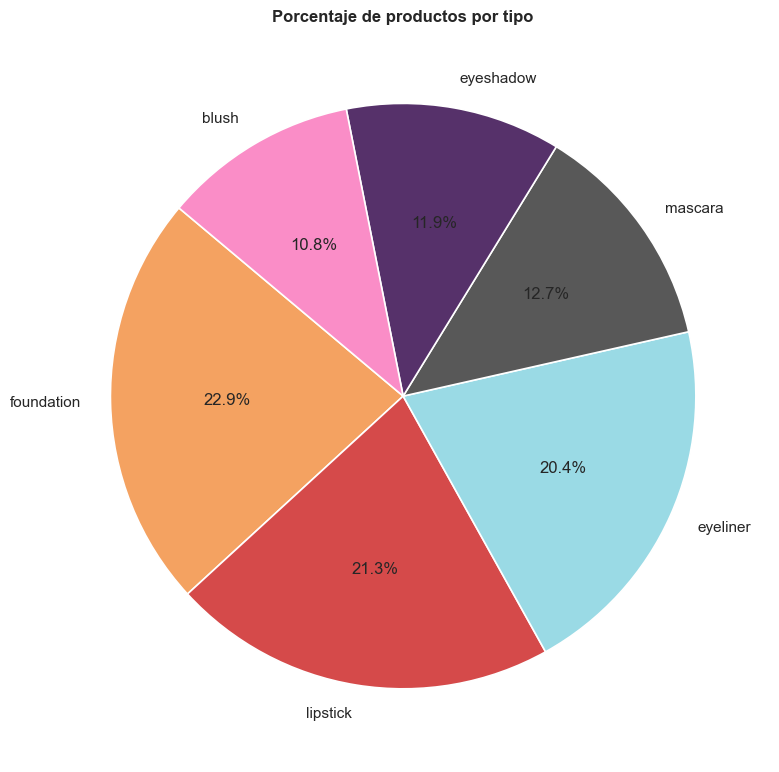

In [99]:
product_type_counts = df_clean["product_type"].value_counts().head(6)

plt.figure(figsize=(8, 8))
plt.pie(
    product_type_counts,
    labels=product_type_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#F4A261", "#D54A4A", "#9ADAE5", "#585858", "#56316A", "#FA8DC7"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
plt.title("Porcentaje de productos por tipo")
plt.tight_layout()
plt.show()


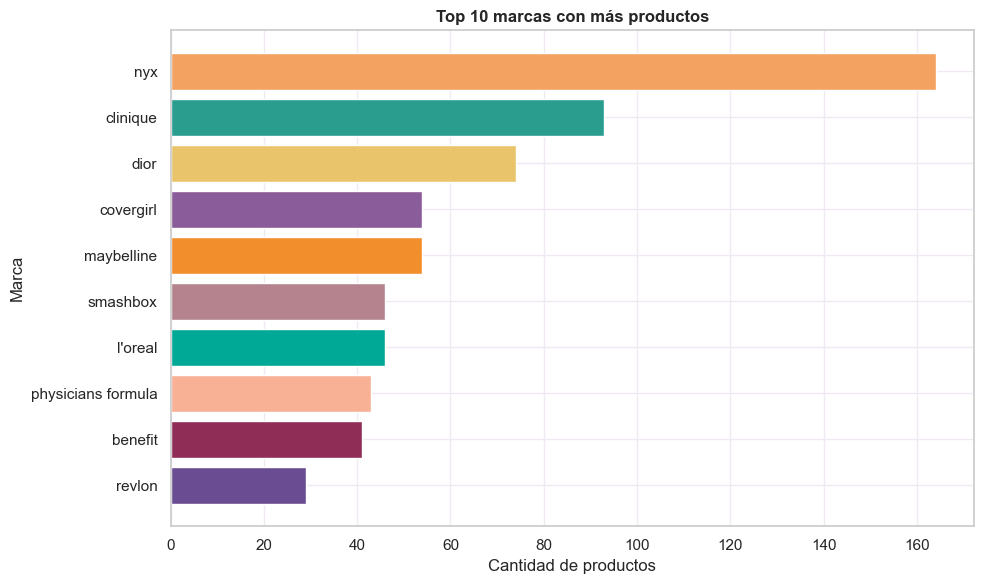

In [89]:
top_brands = df_clean["brand"].value_counts().head(10)
colors_brand = ["#F4A261", "#2A9D8F", "#E9C46A", "#8A5C99", "#F28E2B", "#B5838D", "#00A896", "#F8B195", "#8F2D56", "#6A4C93"]

plt.figure(figsize=(10, 6))
plt.barh(top_brands.index, top_brands.values, color=colors_brand)
plt.title("Top 10 marcas con más productos")
plt.xlabel("Cantidad de productos")
plt.ylabel("Marca")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


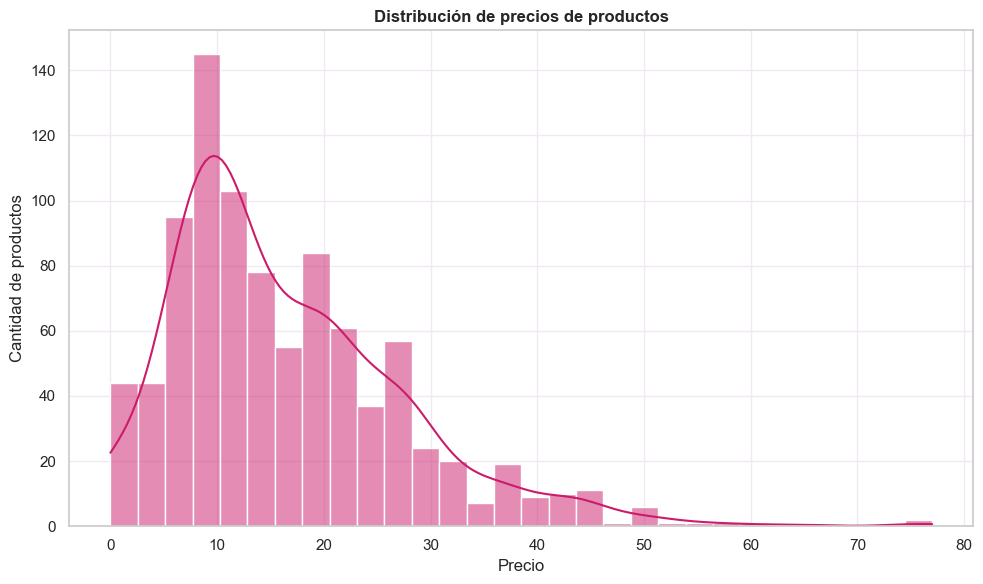

In [100]:
prices = df_clean["price"].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(prices, bins=30, kde=True, color="#CB1B6A")
plt.title("Distribución de precios de productos")
plt.xlabel("Precio")
plt.ylabel("Cantidad de productos")
plt.tight_layout()
plt.show()


### 4.1 Insights adicionales: precio por tipo y rating

Aquí exploramos cómo varía el precio promedio entre los tipos de producto y la distribución de ratings por segmento.


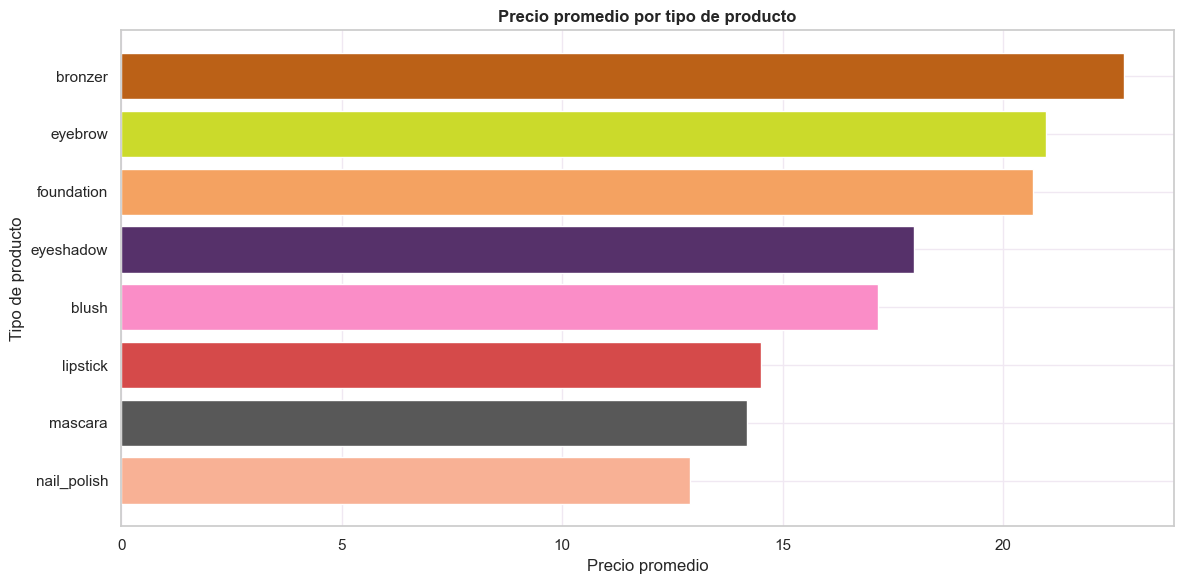

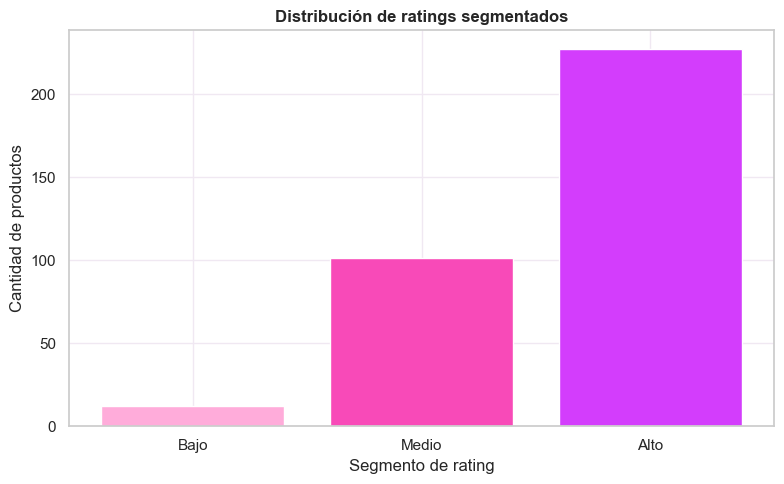

In [109]:
price_by_type = (
    df_clean.groupby("product_type")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
)
colors_type = ["#BB6117", "#CBDA2B", "#F4A261", "#56316A", "#FA8DC7", "#D54A4A", "#585858", "#F8B195"]

plt.figure(figsize=(12, 6))
plt.barh(price_by_type.index, price_by_type.values, color=colors_type)
plt.title("Precio promedio por tipo de producto")
plt.xlabel("Precio promedio")
plt.ylabel("Tipo de producto")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

rating_counts = df_clean["rating_label"].value_counts().reindex(["Bajo", "Medio", "Alto"])
colors_rating = ["#FFACDA", "#F84AB8", "#D33DFC"]

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color=colors_rating)
plt.title("Distribución de ratings segmentados")
plt.xlabel("Segmento de rating")
plt.ylabel("Cantidad de productos")
plt.tight_layout()
plt.show()


In [112]:
df_clean["price_range"].value_counts(dropna=False)

price_range
Budget     328
Regular    312
Premium    277
NaN         14
Name: count, dtype: int64

## Conclusiones

El dataset permite observar diferencias relevantes entre tipos de productos, marcas y precios. La mayor concentración de productos se encuentra en algunos tipos específicos de maquillaje, mientras que varias marcas tienen una participación menor.

La limpieza muestra que hay datos faltantes especialmente en `price` y `rating`, por lo que cualquier análisis cuantitativo debe tratar estos vacíos con cuidado.

Se identificó también que:

- Las categorías `Premium` representan una fracción menor, mientras que los productos `Budget` y `Regular` dominan el portafolio.
- El rating se concentra en las bandas `Medio` y `Alto`, lo cual sugiere valoraciones positivas en la mayoría de los productos.
- El precio promedio varía significativamente según el tipo de producto, lo que es clave para entender la estrategia comercial de las marcas.
- El promedio de `rating` se calculó únicamente sobre los productos que sí tenían rating disponible, por lo que no representa necesariamente a todo el catálogo.
- Algunos productos no traen categoría definida en la API. Para facilitar el análisis, esos valores se etiquetaron como `uncategorized`, lo que permite medir cuántos registros carecen de esa clasificación.
